In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
from collections.abc import Callable

In [30]:
import glob
from datetime import datetime,date
import os
import sys
import gc
import io
import json
import re
import einops
from copy import deepcopy
from pprint import pprint
from collections import OrderedDict

In [31]:
import xarray as xr

In [84]:
patch_new = xr.open_dataset("/cluster/work/climate/dnikolo/IceCloudNet_Data/Mid_lat/TrainingData/2010_01_20/patch_99.nc",decode_times=False)

In [85]:
patch_old = xr.open_dataset("/cluster/work/climate/dnikolo/IceCloudNet_Data/Kai_data/TrainingData/2010_01_20/patch_99.nc")

In [87]:
patch_old

<xarray.Dataset> Size: 3MB
Dimensions:             (y: 128, x: 128, xy: 122, height: 316,
                         sensing_start: 1, sensing_stop: 1)
Coordinates:
  * y                   (y) float64 1kB 2.903e+06 2.906e+06 ... 3.284e+06
  * x                   (x) float64 1kB 1.466e+06 1.463e+06 ... 1.085e+06
  * xy                  (xy) int64 976B 0 1 2 3 4 5 ... 116 117 118 119 120 121
  * height              (height) float32 1kB 2.058e+04 2.052e+04 ... 1.68e+03
  * sensing_start       (sensing_start) datetime64[ns] 8B 2010-01-21T01:00:10...
  * sensing_stop        (sensing_stop) datetime64[ns] 8B 2010-01-21T01:12:41....
Data variables: (12/31)
    ch1                 (y, x) float32 66kB ...
    ch2                 (y, x) float32 66kB ...
    ch3                 (y, x) float32 66kB ...
    ch4                 (y, x) float32 66kB ...
    ch5                 (y, x) float32 66kB ...
    ch6                 (y, x) float32 66kB ...
    ...                  ...
    y_nearest           (xy) float64 976B ...
    time                (xy) datetime64[ns] 976B ...
    day_night_flag      (xy) float32 488B ...
    land_water_mask     (xy) float32 488B ...
    iteration_flag      (xy) float32 488B ...
    clm                 (xy, height) float32 154kB ...
Attributes: (12/19)
    source_file:                  MSG2-SEVI-MSG15-0100-NA-20100121011241.1100...
    proj4_string:                 +proj=geos +lon_0=0 +h=35785831 +x_0=0 +y_0...
    projection_longitude:         0.0
    projection_latitude:          0.0
    projection_altitude:          35785831.0
    satellite_nominal_longitude:  0.0
    ...                           ...
    author:                       Odran Sourdeval (odran.sourdeval@univ-lille...
    references:                   DARDAR-Nice dataset (doi:10.25326/09) / Sou...
    institution:                  Institute for Meteorology (LIM), University...
    history:                      2023-09-06 14:25:45 (UTC): File produced by...
    conventions:                  CF-1.6 where applicable
    licence:                      For non-commercial use only. This data is s...

In [89]:
aux_data = xr.open_dataset("/cluster/work/climate/dnikolo/IceCloudNet_Data/Mid_lat/seviri_aux.nc",decode_times=False)

In [90]:
aux_data

<xarray.Dataset> Size: 87MB
Dimensions:                  (y: 1998, x: 1822)
Coordinates:
  * y                        (y) float32 8kB -2.996e+06 -2.993e+06 ... 2.996e+06
  * x                        (x) float32 7kB 2.732e+06 2.729e+06 ... -2.732e+06
    georef_offset_corrected  uint8 1B ...
    lon0                     float64 8B ...
Data variables:
    lsm                      (y, x) float32 15MB ...
    alt                      (y, x) float32 15MB ...
    pixel_area               (y, x) float32 15MB ...
    satzen                   (y, x) float32 15MB ...
    acq_time                 (y, x) float64 29MB ...
    lon                      (x) float64 15kB ...
    lat                      (y) float64 16kB ...
    latr                     (y) float64 16kB ...
    lonr                     (x) float64 15kB ...
Attributes: (12/13)
    filename:       claas3_level2_aux_data.nc
    title:          CLAAS-3 Level 2 Auxiliary Data
    summary:        This file contains auxiliary data facilitating work with ...
    id:             DOI:10.5676/EUM_SAF_CM/CLAAS/V003
    creator_name:   DE/DWD
    creator_email:  contact.cmsaf@dwd.de
    ...             ...
    institution:    EUMETSAT/CMSAF
    project:        Satellite Application Facility on Climate Monitoring (CM ...
    references:     https://doi.org/10.5676/EUM_SAF_CM/CLAAS/V003
    readme:         http://www.cmsaf.eu/EN/Products/AuxiliaryData/AuxiliaryDa...
    date_created:   2022-07-27T07:36:41Z
    comment:        CLAAS-3 Level 2 data is provided on two different grids b...

In [91]:
dardar_data = xr.open_dataset("/cluster/work/climate/dnikolo/IceCloudNet_Data/DARDAR_Nice/2010/2010_01_20/DARNI_PRO_L2_v1.00_20100120071115.nc")

In [92]:
dardar_data

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 37082, height: 436)
Coordinates:
  * height            (height) float32 2kB 2.508e+04 2.502e+04 ... -1.02e+03
Dimensions without coordinates: time
Data variables: (12/22)
    dtime             (time) float32 148kB ...
    base_time         datetime64[ns] 8B ...
    lat               (time) float32 148kB ...
    lon               (time) float32 148kB ...
    ps                (time) float32 148kB ...
    plev              (time, height) float32 65MB ...
    ...                ...
    clm               (time, height) float32 65MB ...
    instrument_flag   (time, height) int8 16MB ...
    iteration_flag    (time) float32 148kB ...
    nightday_flag     (time) float32 148kB ...
    mixedphase_flag   (time, height) float32 65MB ...
    layer_index       (time, height) float32 65MB ...
Attributes:
    title:        DARDAR-Nice / Profiles of the ice crystal number concentrat...
    version:      v1.00
    source:       Satellite observations (CPR/CloudSat and CALIOP/CALIPSO)
    author:       Odran Sourdeval (odran.sourdeval@univ-lille.fr)
    references:   Sourdeval et al, 2018 (doi:10.5194/acp-2018-20) / Gryspeerd...
    institution:  Institute for Meteorology (LIM), University of Leipzig / La...
    history:      2018-12-14 04:26:38 (UTC): File produced by DARDAR-Ni/run_d...
    conventions:  CF-1.6 where applicable
    licence:      For non-commercial use only. This data is subject to the IC...

In [86]:
patch_new

<xarray.Dataset> Size: 3MB
Dimensions:             (y: 128, x: 128, xy: 170, height: 316,
                         sensing_start: 1, sensing_stop: 1)
Coordinates:
  * y                   (y) float64 1kB -2.783e+06 -2.78e+06 ... -2.402e+06
  * x                   (x) float64 1kB 2.642e+06 2.639e+06 ... 2.261e+06
  * xy                  (xy) int64 1kB 220 221 222 223 224 ... 386 387 388 389
  * height              (height) float32 1kB 2.058e+04 2.052e+04 ... 1.68e+03
  * sensing_start       (sensing_start) int64 8B 0
  * sensing_stop        (sensing_stop) int64 8B 0
Data variables: (12/28)
    ch1                 (y, x) float32 66kB ...
    ch2                 (y, x) float32 66kB ...
    ch3                 (y, x) float32 66kB ...
    ch4                 (y, x) float32 66kB ...
    ch5                 (y, x) float32 66kB ...
    ch6                 (y, x) float32 66kB ...
    ...                  ...
    latitude            (xy) float32 680B ...
    x_nearest           (xy) float64 1kB ...
    y_nearest           (xy) float64 1kB ...
    day_night_flag      (xy) float32 680B ...
    iteration_flag      (xy) float32 680B ...
    clm                 (xy, height) float32 215kB ...
Attributes: (12/19)
    source_file:                  MSG2-SEVI-MSG15-0100-NA-20100120235741.9310...
    proj4_string:                 +proj=geos +lon_0=0 +h=35785831 +x_0=0 +y_0...
    projection_longitude:         0.0
    projection_latitude:          0.0
    projection_altitude:          35785831.0
    satellite_nominal_longitude:  0.0
    ...                           ...
    author:                       Odran Sourdeval (odran.sourdeval@univ-lille...
    references:                   Sourdeval et al, 2018 (doi:10.5194/acp-2018...
    institution:                  Institute for Meteorology (LIM), University...
    history:                      2018-12-14 04:09:44 (UTC): File produced by...
    conventions:                  CF-1.6 where applicable
    licence:                      For non-commercial use only. This data is s...

In [32]:
import omegaconf
from omegaconf import OmegaConf
import comet_ml

In [33]:

import pytorch_lightning as pl


In [34]:
import seaborn as sns
from matplotlib.colors import LogNorm, Normalize
sns.set_theme(style="ticks")

In [35]:
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio
from sklearn.metrics import ConfusionMatrixDisplay

In [36]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib import colors, ticker
from matplotlib.colors import LogNorm

In [37]:
import cartopy.crs as ccrs

In [38]:
from bokeh import palettes

In [39]:
import holoviews as hv

In [40]:
import hvplot.pandas  # noqa

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
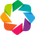

In [41]:
hv.extension('bokeh')

In [42]:
import sys
sys.path.append("../")

In [43]:
from data.data_module import VerticalCloudDataModule, LogTransform,LogTransform2D, get_variable_stat

from data.data_utils import load_patches, sort_overpass_indices, get_overpass_direction

from helpers.comet_helpers import get_patch_ids, load_experiment, get_hparams, get_trained_model, get_trained_experiment, get_dm, get_data_module, get_asset_id, dm_hparams_config, model_hparams_config, dm_overwrite_hparams, model_overwrite_hparams
from helpers.callbacks import *

from model.losses import *

from model.LightningModel import VerticalCloudCubeModel

In [44]:
from data.data_utils import get_horizontal_cloud_coverage, horizontal_cover_by_level, UnNormalize, get_height_level_range
from helpers.misc_helpers import  nested_set
from helpers.comet_helpers import log_image_to_comet

In [45]:
from evaluate.eval_plots import *

In [46]:
from model.DiscriminatorModel import IceCloudNetDisc

In [47]:
from inference.inference import load_discriminator_model, load_model

***

### Configs

In [48]:
y_hat_color = "#30A2DA"
dardar_color = "#FD654B"

hv.extension('matplotlib')

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

### User defined functions

In [49]:
def get_hparams(experiment, hparams_config,overwrite_params,print_hparams=False):
    hparams = dict()
    for param in experiment.get_parameters_summary():
        p_name = param["name"]
        if p_name not in hparams_config.keys():
            continue
        elif param["valueCurrent"] == "iwc":
            param_value = "iwc"
        elif param["valueCurrent"] in ["None",'null']:
            param_value = None
        elif hparams_config[p_name] in (list,tuple,dict):
            param_value_str = param["valueCurrent"]
            param_value = json.loads(param_value_str)
        elif hparams_config[p_name] == bool:
            if param["valueCurrent"] == "false":
                param_value = False
            else:
                param_value = True
        elif hparams_config[p_name] == datetime.date:
            param_value = datetime.strptime(param["valueCurrent"],"%Y-%m-%d").date()
        elif hparams_config[p_name] in [int,float,str,np.float64]:
            param_value = hparams_config[p_name](param["valueCurrent"])
        elif hparams_config[p_name] == LogTransform:
            args = ["constant", "scaler"]
            args_dict = dict()
            input_string = param["valueCurrent"]
            for arg in args:
                match = re.search(fr'{arg}=(\d+\.*)', input_string)
                # Check if the pattern was found
                if match:
                    # Extract the matched value
                    args_dict[arg] = np.float64(match.group(1))
            param_value=LogTransform(**args_dict)
    
        else:
            print(f"No value for {p_name} available/possible to parse → set manually")
            param_value = "SetManually"
        hparams[p_name] = param_value

    # set params to overwrite
    print(overwrite_params)
    for key,val in overwrite_params.items():
        print(f"Set {key} manually with value {val}")
        hparams[key]=val
        
    if print_hparams:
        print("-------")
        print("hparams")
        print("-------")
        pprint(hparams,depth=1)
    return hparams

def get_trained_model(experiment, model_hparams):
    vertical_cloud_model = VerticalCloudCubeModel(**model_hparams)
    exp_key = experiment.get_metadata()["experimentKey"]
    try:
        # load local
        path = glob.glob(os.path.join("/cluster/climate/dnikolo/IceCLoudNet_model/ice_cloud_net/src/model_checkpoints", exp_key, "*.ckpt"))[0]
        pretrained_state_dict = torch.load(path)["state_dict"]
        print("loaded model from disk")
    except IndexError:
        # load from comet
        asset_id = experiment.get_model_asset_list("ice_net")[0]["assetId"]
        model_binary = experiment.get_asset(asset_id, return_type="binary")
        pretrained_state_dict = torch.load(io.BytesIO(model_binary))
        print("loaded model from comet")
    vertical_cloud_model.load_state_dict(pretrained_state_dict)
    
    return vertical_cloud_model

def get_data_module(experiment, dm_hparams):
    return VerticalCloudDataModule(**dm_hparams)

def get_dm(experiment_id, dm_overwrite_params,dm_hparams_config=dm_hparams_config):
    experiment = load_experiment(experiment_name=experiment_id)
    print("loaded experiment from comet")
    
    dm_hparams = get_hparams(experiment, 
                             print_hparams=True,
                             hparams_config=dm_hparams_config,
                             overwrite_params=dm_overwrite_params)
    
    dm = VerticalCloudDataModule(**dm_hparams)
    dm.setup(stage="fit")
    
    return dm 

def get_trained_experiment(experiment_id,
                           model_overwrite_params,
                           model_hparams_config=model_hparams_config):

    experiment = load_experiment(experiment_name=experiment_id)
    print("loaded experiment from comet")
       
    model_hparams = get_hparams(experiment, 
                                hparams_config=model_hparams_config, 
                                overwrite_params=model_overwrite_params,
                                print_hparams=False)
    
    model = VerticalCloudCubeModel(**model_hparams)

    # load local
    exp_key = experiment.get_metadata()["experimentKey"]
    try:
        path = glob.glob(os.path.join("/cluster/work/climate/dnikolo/IceCLoudNet_model/ice_cloud_net/src/model_checkpoints", exp_key, "*.ckpt"))[0]
        pretrained_state_dict = torch.load(path)["state_dict"]
        print("loaded model from disk")
    except IndexError:
        # load from comet
        asset_id = experiment.get_model_asset_list("ice_net")[0]["assetId"]
        model_binary = experiment.get_asset(asset_id, return_type="binary")
        pretrained_state_dict = torch.load(io.BytesIO(model_binary))
        print("loaded model from comet")
    model.load_state_dict(pretrained_state_dict)
    
    return experiment, model

In [50]:
# type(exp)

In [51]:
# type(load_experiment("famous_elk_2849"))

#### Create Inference data (execute hidden cells)

In [52]:
def create_inference_data(model, dataloader,store_3d_data = False,load_meta_data = True,split="val",stop_at_step=10):

    seviri_data = []
    era5_data = []
    overpass_mask_data = []
    patch_idx_data = []
    dardar_cube_data = []
    y_hat_cube_data = []
    y_hat_profile_data_list = []
    dardar_profile_data_list = []
    y_hat_cloud_cover_data = []
    dardar_cloud_cover_data = []
    meta_data = []

    out_channels = model.out_channels
    
    # manually set level thickness for calculating horizontal cloud cover
    if out_channels >= 256:
        n_level_aggregation=16
    elif out_channels == 64:
        n_level_aggregation = 4
    elif out_channels == 55:
        n_level_aggregation = 5
    elif out_channels == 16:
        n_level_aggregation = 1
    else:
        raise ValueError(f"n_level_aggregation for out channels {n_level_aggregation}")
        
    if isinstance(model, IceCloudNetDisc):
        n_targets = model.unet.prediction_heads
    else:
        n_targets = model.prediction_heads
        
    
    for step, data in enumerate(dataloader):
        if step % 10 == 0: print(step)
        
        if isinstance(model, IceCloudNetDisc):
            seviri, era5, dardar, overpass_mask, md, patch_idx = model.get_input(data, split="val")
            seviri = seviri.float() # this means float32, double() is float64,
            overpass_mask = overpass_mask.long()
            dardar = dardar.float()
        else:
            seviri, era5, dardar, overpass_mask, md, patch_idx = data
        
        if torch.cuda.is_available():
            seviri = seviri.to(torch.device("cuda"))
            md = md.to(torch.device("cuda"))

        with torch.no_grad():
            if model.meta_data_embedding:
                y_hat = model(seviri, md)
            else:
                y_hat = model(seviri)

        y_hat = y_hat.cpu()
        dardar = dardar.cpu()

        # for each sample extract profile
        for idx in range(y_hat.shape[0]):
            y_hat_profile = torch.masked_select(y_hat[idx], overpass_mask[idx].bool())
            y_hat_profile = einops.rearrange(y_hat_profile, '(c z overpass) -> overpass c z',c=n_targets, z=out_channels).squeeze() # squeeze so shape is (overpass, z) for single target
            
            dardar_profile = torch.masked_select(dardar[idx], overpass_mask[idx].bool())
            dardar_profile = einops.rearrange(dardar_profile, '(c z overpass) -> overpass c z',c=n_targets, z=out_channels).squeeze()

            y_hat_profile_data_list.append(y_hat_profile)
            dardar_profile_data_list.append(dardar_profile)

            # calculate horizontal cloud cover per level
            if n_targets == 1:
                dardar_cloud_cover = horizontal_cover_by_level(dardar_profile,n_level_aggregation=n_level_aggregation)
                y_hat_cloud_cover = horizontal_cover_by_level(y_hat_profile,n_level_aggregation=n_level_aggregation)
            else:
                # use only single target
                dardar_cloud_cover = horizontal_cover_by_level(dardar_profile[:,0],n_level_aggregation=n_level_aggregation)
                y_hat_cloud_cover = horizontal_cover_by_level(y_hat_profile[:,0],n_level_aggregation=n_level_aggregation)
                
            dardar_cloud_cover_data.append(dardar_cloud_cover)
            y_hat_cloud_cover_data.append(y_hat_cloud_cover)        

        era5_data.append(era5.cpu())
        overpass_mask_data.append(overpass_mask.cpu())
        patch_idx_data.append(patch_idx.cpu())
        seviri_data.append(seviri.cpu())
        meta_data.append(md.cpu())

        if store_3d_data:
            dardar_cube_data.append(dardar.cpu())
            y_hat_cube_data.append(y_hat.cpu())

        # load meta_data → could be done in get_item directly to prevent loading each path twice
        # if load_meta_data:
            # for patch_id in patch_idx:
                # patch = xr.open_dataset(os.path.join(dataloader.dataset.root,dataloader.dataset.patch_ids[patch_id]))
                # meta_data["lat"].append(patch.latitude.mean().values.item())
                # meta_data["lon"].append(patch.longitude.mean().values.item())
                # meta_data["lwm"].append(stats.mode(patch.land_water_mask).mode.item())
                # meta_data["day_night_flag"].append(patch.day_night_flag.max().values.item())
                # meta_data["time_of_day"].append(patch.sensing_stop.dt.hour.values.item())
                # meta_data["month"].append(patch.sensing_stop.dt.month.values.item())
        
        if stop_at_step:
            if step==stop_at_step: break

    # concat input data
    overpass_mask_data = torch.concat(overpass_mask_data)
    patch_idx_data = torch.concat(patch_idx_data)
    seviri_data = torch.concat(seviri_data)
    era5_data = torch.concat(era5_data)
    meta_data = torch.concat(meta_data)

    # concat cloud cover
    dardar_cloud_cover_data = torch.concat(dardar_cloud_cover_data)
    y_hat_cloud_cover_data  = torch.concat(y_hat_cloud_cover_data)

    # if load_meta_data:
        # meta_data["day_night_flag"] = torch.tensor(meta_data["day_night_flag"])
        # meta_data["lwm"] = torch.tensor(meta_data["lwm"])
        # meta_data["lon"] = torch.tensor(meta_data["lon"])
        # meta_data["lat"] = torch.tensor(meta_data["lat"])

    # profile data, and cube data are in lists with length |samples|, other data is in concatenated tensors already
    eval_data = dict(overpass_mask_data=overpass_mask_data,
         patch_idx_data=patch_idx_data,
         seviri_data=seviri_data,
         era5_data=era5_data,
         dardar_profile_data_list=dardar_profile_data_list,
         y_hat_profile_data_list=y_hat_profile_data_list,
         dardar_cloud_cover_data=dardar_cloud_cover_data,
         y_hat_cloud_cover_data =y_hat_cloud_cover_data,
         y_hat_cube_data=y_hat_cube_data,
         dardar_cube_data=dardar_cube_data,
         meta_data=meta_data)
    
    return eval_data

def get_profile_data(eval_data, meta_data_filter=None,target_transform=LogTransform(scaler=1e7),selected_height_levels=None):
    """Returns concatenated y_hat, dardar data
    
    args:
        eval_data
        meta_data_filter (Tuple): (meta data variable index, value)
    
    """
    if meta_data_filter:
        filtered_idxs = np.where(np.array(eval_data["meta_data"][:,meta_data_filter[0]])==meta_data_filter[1])[0]

        y_hat_profile_data_list = [eval_data["y_hat_profile_data_list"][i] for i in filtered_idxs]
        dardar_profile_data_list = [eval_data["dardar_profile_data_list"][i] for i in filtered_idxs]
    else:
        y_hat_profile_data_list = eval_data["y_hat_profile_data_list"]
        dardar_profile_data_list = eval_data["dardar_profile_data_list"]

    # profile data
    dardar_profile_data = torch.concat(dardar_profile_data_list)
    y_hat_profile_data = torch.concat(y_hat_profile_data_list)
    # convert to original scale → this is what we mainly work with in the evaluation
    dardar = target_transform.inverse_transform(dardar_profile_data)
    y_hat = target_transform.inverse_transform(y_hat_profile_data)
    
    if selected_height_levels is not None:
        if len(y_hat.shape)==2:
            dardar = dardar[:, selected_height_levels]
            y_hat = y_hat[:, selected_height_levels]
        else:
            dardar = dardar[:,:, selected_height_levels]
            y_hat = y_hat[:,:, selected_height_levels]
    
    return y_hat, dardar

def get_cube_data(eval_data,target_transform=LogTransform(scaler=1e7)):
    """todo: add filter and dardar data"""
    y_hat_cube = torch.concat(eval_data["y_hat_cube_data"])
    y_hat_cube = target_transform.inverse_transform(y_hat_cube) # transform to original space
    # y_hat_cube_flat = einops.rearrange(y_hat_cube, 'b z y x -> (b y x) z ') # rearrange cube data to 2d: n, 256
    
    return y_hat_cube#, y_hat_cube_flat

def run_evaluation(y_hat, 
                   dardar, 
                   eval_data, 
                   exp, 
                   target_variable="iwc",
                   target_transform=LogTransform(scaler=1e7),
                   height_levels:np.ndarray=get_height_level_range(1680,16980,step=60),
                   cloud_thres=0,
                   log_image_kwargs=dict(),
                   suffix=""):
    """runs evaluation given inference/ground truth data and plots eval plots to comet
    
    todo: alternatively display plots inline
    
    """
    if suffix != "":
        suffix = f"_{suffix}"
    
    if target_variable=="icnc_5um":
        target_variable="nice"
    
    level_thickness = np.abs(height_levels[0]-height_levels[1])
       
    # cloud occurance per height level
    hv.extension("bokeh")
    df, occurance_p = cloud_occurance_per_height_level(y_hat, dardar, height_levels=height_levels)
    log_image(occurance_p, f"cloud_occurance{suffix}", **log_image_kwargs,exp_obj=exp)
    
    # metrics per level
    df, metric_p = metrics_per_level(y_hat, dardar, cloud_thres=cloud_thres, height_levels=height_levels, target_transform=target_transform,n_level_aggregation=int(height_levels.shape[0]/16)) # todo better heuristic for n_level_aggregation 
    log_image(metric_p,f"performance_metrics_levels{suffix}", **log_image_kwargs,exp_obj=exp)
    

    # iwc per height level
    y_hat_height_iwc_df, y_hat_height_iwc_plt = iwc_per_height_df(y_hat,color=y_hat_color,plt_q10=False, height_levels=height_levels,target_variable=target_variable)
    dardar_height_iwc_df, dardar_height_iwc_plt = iwc_per_height_df(dardar,color=dardar_color,plt_q10=False, height_levels=height_levels,target_variable=target_variable)
    p = (y_hat_height_iwc_plt * dardar_height_iwc_plt).opts(fontscale=1.5)
    log_image(p, f"iwc_height{suffix}", **log_image_kwargs,exp_obj=exp)
    
    # iwc vs iwc
    df, g = iwc_vs_iwc_plt(y_hat, dardar,target_variable=target_variable)
    log_image(g, f"iwc_vs_iwc{suffix}", **log_image_kwargs,exp_obj=exp)
    
    
    # todo: was displaying only the last plot, same problem for zonal mean count
    # for p in height_plts:
        # log_image_to_comet(exp, p,image_name=p.fig._suptitle.get_text())
    
    # metrics 
    metric_dict = get_metrics(y_hat, dardar, cloud_thres=cloud_thres, target_transform=target_transform)
    
    if suffix != "":
        metric_dict = {f"{key}{suffix}":value for key,value in metric_dict.items()}
    
    pprint(metric_dict)
    
    if suffix == "":
        # todo implement filter for day/night below
        # horizontal cloud cover
        all_data_plt, summary_line_plt, hor_cloud_cover_metrics = horizontal_cloud_cover(eval_data["dardar_cloud_cover_data"],eval_data["y_hat_cloud_cover_data"],height_levels=height_levels)
        log_image(all_data_plt, f"horizontal_cloud_cover{suffix}", **log_image_kwargs,exp_obj=exp)
        log_image(summary_line_plt, f"horizonal_cloud_cover_level_stats{suffix}", **log_image_kwargs,exp_obj=exp)
    
    if suffix in ["" ,"_nice"]:
        print("calc zonal/iwp means")
        height_levels=get_height_level_range(1680,16980,step=240)[:-1]
        # zonal means
        fig_zonal = zonal_mean(eval_data["y_hat_profile_data_list"],eval_data["dardar_profile_data_list"],eval_data["meta_data"][:,0],height_levels=height_levels,min_count=250,target_variable=target_variable,target_transform=target_transform)
        log_image(fig_zonal, f"zonal_mean{suffix}", **log_image_kwargs,exp_obj=exp)

        # iwp mean
        #fig,dardar_Z,y_hat_Z = iwp_regional_mean(eval_data["y_hat_profile_data_list"],eval_data["dardar_profile_data_list"],eval_data["meta_data"][:,0],eval_data["meta_data"][:,1],level_thickness=level_thickness,height_levels=height_levels,grid_size=4,target_variable=target_variable,target_transform=target_transform)
        #log_image(fig, f"iwp_mean{suffix}", **log_image_kwargs,exp_obj=exp)
    

def eval_pipeline(exp_config, 
                  eval_kwargs, 
                  meta_data_filter=None, 
                  dm_experiment_id="famous_elk_2849",
                  dm_overwrite_hparams=dm_overwrite_hparams,
                  log_image_kwargs=dict(display_inline=True, log_to_overleaf=False, log_to_comet=False),
                  run_eval=True):

    experiment_id = exp_config["experiment_id"]
    print(f"start eval pipeline for {experiment_id}")
    
    dm = get_dm(dm_experiment_id, dm_overwrite_hparams)
    val_dataloader = dm.val_dataloader()
    print("loaded dm")
    
    if exp_config["type"]=="unet_only":
        exp, model = get_trained_experiment(experiment_id,exp_config["model_overwrite_hparams"])
    elif exp_config["type"]=="unet_disc":
        exp, model, conf = load_discriminator_model(experiment_id)
    else:
        raise ValueError

    model = model.to(torch.device("cuda"))
    model.eval()
    
    eval_data = create_inference_data(model, val_dataloader, **eval_kwargs)
    #todo implement loop for meta data filter
    y_hat, dardar = get_profile_data(eval_data, meta_data_filter=meta_data_filter,target_transform=dm.target_transform)
    y_hat_night, dardar_night = get_profile_data(eval_data, meta_data_filter=(3,1),target_transform=dm.target_transform)
    y_hat_day, dardar_day = get_profile_data(eval_data, meta_data_filter=(3,0),target_transform=dm.target_transform)
    
    if eval_kwargs["store_3d_data"]:
        y_hat_cube = get_cube_data(eval_data,target_transform=dm.target_transform)
    else:
        y_hat_cube = None#, None
    print("generated eval data")
    
    # define height levels for eval
    if dm.fold_to_level_thickness:
        level_thickness = 60*dm.fold_to_level_thickness
    else:
        level_thickness = 60
    height_levels = get_height_level_range(dm.height_levels[1],dm.height_levels[0],level_thickness)
    height_levels = height_levels[-y_hat.shape[1]:] # height levels has to have the same shape as predictions / cut off highest hight if necessary
    
    target_variable = "iwc" if dm.target_variable=="iwc" else "nice"
    
    # run evaluation plot pipeline
    if run_eval:
        try:
            run_evaluation(y_hat=y_hat,dardar=dardar,eval_data=eval_data,exp=exp,target_variable=target_variable,target_transform=dm.target_transform,height_levels=height_levels, log_image_kwargs=log_image_kwargs)
            print("saved plots to comet")
            run_evaluation(y_hat=y_hat_day,dardar=dardar_day,eval_data=eval_data,exp=exp,target_variable=target_variable,target_transform=dm.target_transform,height_levels=height_levels, log_image_kwargs=log_image_kwargs,suffix="day")
            print("saved day plots to comet")
            run_evaluation(y_hat=y_hat_night,dardar=dardar_night,eval_data=eval_data,exp=exp,target_variable=target_variable,target_transform=dm.target_transform,height_levels=height_levels, log_image_kwargs=log_image_kwargs,suffix="night")
            print("saved night plots to comet")
        except BaseException as ex:
            print(ex)
    
    return exp, dm, model, eval_data, y_hat, dardar, y_hat_cube

def log_image(p, 
              image_name, 
              display_inline=True,
              log_to_overleaf=False, 
              overleaf_dir="",
              log_to_comet=False, 
              exp_obj=None, 
              comet_log_kwargs=dict(overwrite=True)):
    if log_to_comet:
        assert exp_obj is not None, "provide comet experiment object"
        log_image_to_comet(exp_obj,p,image_name,log_kwargs=comet_log_kwargs)
        
    if log_to_overleaf:
        fpath = os.path.join(overleaf_dir, f"{image_name}.png")
        #hvplot
        if "holoviews" in str(type(p)):
            hv.save(p,fpath,dpi=600)
        # matplotlib
        else:
        # elif isinstance(p,plt.Figure):
            p.savefig(fpath,dpi=600)
            if isinstance(p,plt.Figure):
                plt.close(p)
            else:
                # seaborn
                plt.close(p.fig)
    if display_inline:    
        if isinstance(p, hv.core.overlay.Overlay) or isinstance(p,hv.core.overlay.NdOverlay):
            display(p)
        else:
            plt.show()


In [53]:
plt_kwargs_commons = {'var_range': 
                      {'iwc': (1e-07, 0.001), 
                       'nice': (1e2, 1e6)},
                      'var_range_log': 
                      {'iwc': (-7, -3), 
                       'nice': (2, 6)},
                      'axis_title':
                       {'iwc': r'IWC [kg m$^{-3}$]',
                        'nice': r'Nice [m$^{-3}$]'}}

In [54]:
pl.seed_everything(13)

Seed set to 13


13

### Get patch_ids

In [63]:
data_dir = "../helper_files"
with open(os.path.join(data_dir,"train_pids.json"), 'r') as file:
    train_patch_ids = json.load(file)

# with open(os.path.join(data_dir,"val_pids.json"), 'r') as file:
with open(os.path.join(data_dir,"val_pids_mid_lat_test_06_04_26.json"), 'r') as file:
    val_patch_ids = json.load(file)
    
# with open(os.path.join(data_dir,"test_pids.json"), 'r') as file:
# with open(os.path.join(data_dir,"test_pids.json"), 'r') as file:
#     val_patch_ids = json.load(file)

### Load model & data module

In [70]:
# todo set `data_dir` to path containing TrainingData
# model, dm = load_model(data_dir="/cluster/work/climate/dnikolo/IceCLoudNet_model/ice_cloud_net/",
#                    train_patch_ids=[],
#                    val_patch_ids=val_patch_ids,
#                    model_conf_filepath="../model_configs/ice_cloud_net_conf.yaml",
#                    model_checkpoint_dir="../model_checkpoints")
model, dm = load_model(data_dir="/cluster/work/climate/dnikolo/IceCloudNet_Data/Mid_lat/",
                   train_patch_ids=[],
                   val_patch_ids=val_patch_ids,
                   model_conf_filepath="../model_configs/ice_cloud_net_conf.yaml",
                   model_checkpoint_dir="../model_checkpoints")

Seed set to 13


loaded 0 patch ids
loaded 9 patch ids
load model from path: ../model_checkpoints/ice_cloud_net_pretrained.ckpt
loaded model from disk


### Run evaluation pipeline

#### Get eval data 

In [73]:
eval_kwargs = dict(store_3d_data=False,load_meta_data = True,split="val",stop_at_step=250)
meta_data_filter = {}

In [75]:
%%time
model.eval()

eval_data = create_inference_data(model, dm.val_dataloader(), **eval_kwargs)
#todo implement loop for meta data filter

/cluster/work/climate/dnikolo/IceCLoudNet_model/ice_cloud_net/src/evaluate/../data/data_module.py:422: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  patch = xr.merge([patch, aux_patch])
/cluster/work/climate/dnikolo/IceCLoudNet_model/ice_cloud_net/src/evaluate/../data/data_module.py:422: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  patch = xr.merge([patch, aux_patch])


AttributeError: Caught AttributeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/cluster/software/stacks/2024-06/spack/opt/spack/linux-ubuntu22.04-x86_64_v3/gcc-12.2.0/python-3.11.6-ukhwpjnwzzzizek3pgr75zkbhxros5fq/lib/python3.11/site-packages/torch/utils/data/_utils/worker.py", line 308, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/cluster/software/stacks/2024-06/spack/opt/spack/linux-ubuntu22.04-x86_64_v3/gcc-12.2.0/python-3.11.6-ukhwpjnwzzzizek3pgr75zkbhxros5fq/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 51, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/cluster/software/stacks/2024-06/spack/opt/spack/linux-ubuntu22.04-x86_64_v3/gcc-12.2.0/python-3.11.6-ukhwpjnwzzzizek3pgr75zkbhxros5fq/lib/python3.11/site-packages/torch/utils/data/_utils/f

In [68]:
overpass_length = torch.sum(eval_data["overpass_mask_data"],dim=(1,2))

NameError: name 'eval_data' is not defined

In [ ]:
overpass_length = overpass_length[overpass_length>256]

In [ ]:
if dm.fold_to_level_thickness:
    level_thickness = 60*dm.fold_to_level_thickness
else:
    level_thickness = 60
height_levels = get_height_level_range(dm.height_levels[1],dm.height_levels[0],level_thickness)
height_levels = height_levels[-model.out_channels:] # height levels has to have the same shape as predictions / cut off highest hight if necessary

In [ ]:
selected_height_levels = height_levels > 3800

In [ ]:
y_hat_iwc, dardar_iwc = get_profile_data(eval_data, meta_data_filter=None,target_transform=LogTransform(scaler=1e7),selected_height_levels=selected_height_levels)

In [ ]:
y_hat_iwc = y_hat_iwc[:,0]
dardar_iwc = dardar_iwc[:,0]

In [ ]:
# Drago comment
y_hat_night_iwc, dardar_night_iwc = get_profile_data(eval_data, meta_data_filter=(3,1),target_transform=LogTransform(scaler=1e7),selected_height_levels=selected_height_levels)
y_hat_day_iwc, dardar_day_iwc = get_profile_data(eval_data, meta_data_filter=(3,0),target_transform=LogTransform(scaler=1e7),selected_height_levels=selected_height_levels)

In [ ]:
# Drago comment
y_hat_night_iwc = y_hat_night_iwc[:,0]
dardar_night_iwc = dardar_night_iwc[:,0]

y_hat_day_iwc = y_hat_day_iwc[:,0]
# dardar_day_iwchttps://jupyter.euler.hpc.ethz.ch/user/dnikolo/lab/tree/cluster/work/climate/dnikolo/IceCLoudNet_model/ice_cloud_net/src/evaluate/cluster/software/stacks/2024-06/spack/opt/spack/linux-ubuntu22.04-x86_64_v3/gcc-12.2.0/python-3.11.6-ukhwpjnwzzzizek3pgr75zkbhxros5fq/lib/python3.11/multiprocessing/queues.py#line=270 = dardar_day_iwc[:,0]

In [ ]:
# get y_hat_cube n, z,y,x
if eval_kwargs["store_3d_data"]:
    y_hat_cube_iwc = torch.concat(eval_data["y_hat_cube_data"])
    y_hat_cube_iwc = dm.target_transform.inverse_transform(y_hat_cube_iwc)

In [ ]:
nice_logtrans = LogTransform(scaler=1e-2)

In [ ]:
y_hat_nice, dardar_nice = get_profile_data(eval_data, meta_data_filter=meta_data_filter,target_transform=nice_logtrans,selected_height_levels=selected_height_levels)

In [ ]:
y_hat_nice = y_hat_nice[:,1]
dardar_nice = dardar_nice[:,1]

In [ ]:
y_hat_night_nice, dardar_night_nice = get_profile_data(eval_data, meta_data_filter=(3,1),target_transform=nice_logtrans,selected_height_levels=selected_height_levels)
y_hat_day_nice, dardar_day_nice = get_profile_data(eval_data, meta_data_filter=(3,0),target_transform=nice_logtrans,selected_height_levels=selected_height_levels)

In [ ]:
y_hat_night_nice = y_hat_night_nice[:,1]
dardar_night_nice = dardar_night_nice[:,1]

y_hat_day_nice = y_hat_day_nice[:,1]
dardar_day_nice = dardar_day_nice[:,1]

In [ ]:
# get y_hat_cube n, z,y,x
if eval_kwargs["store_3d_data"]:
    y_hat_cube_nice = torch.concat(eval_data["y_hat_cube_data"])
    y_hat_cube_nice = dm.target_transform.inverse_transform(y_hat_cube_nice)

In [ ]:
y_hat = y_hat_iwc
dardar = dardar_iwc

In [ ]:
y_hat_night = y_hat_night_iwc
dardar_night = dardar_night_iwc

y_hat_day = y_hat_day_iwc
dardar_day = dardar_day_iwc

In [ ]:
height_levels = height_levels[selected_height_levels]

In [ ]:
cloud_percentage = (dardar>0).sum() / (dardar>=0).sum()
print(f"% of cloudy pixels {cloud_percentage:.2f}")

In [ ]:
cloud_percentage = (dardar>0).sum() / (dardar>=0).sum()
print(f"% of cloudy pixels {cloud_percentage:.2f}")

### Run plotting

In [51]:
%matplotlib inline

:NdOverlay   [Variable]
   :Curve   [index]   (value)

:NdOverlay   [Variable]
   :Curve   [index]   (value)

min_n_per_height 236.595
min_n_per_height 263.301


:Overlay
   .Curve.I  :Curve   [index]   (iwc_median)
   .Area.I   :Area   [index]   (iwc_q25,iwc_q75)
   .Curve.II :Curve   [index]   (iwc_median)
   .Area.II  :Area   [index]   (iwc_q25,iwc_q75)

:Overlay
   .HexTiles.I :HexTiles   [IceCloudNet,Dardar]
   .Curve.I    :Curve   [x]   (y)
   .Curve.II   :Curve   [IceCloudNet]   (mean)
   .Area.I     :Area   [IceCloudNet]   (lower,upper)
   .Text.I     :Text   [x,y]

{'accuracy': 0.9659059618674121,
 'corr': 0.6426848230601746,
 'corr_incloud': 0.6206072714373604,
 'mae': 3.4870979561674176e-06,
 'mae_incloud': 4.6355802624020725e-05,
 'precision': 0.7930704368224181,
 'r2': 0.41154342889785767,
 'r2_incloud': 0.37241530418395996,
 'r2_log': 0.6623005867004395,
 'recall': 0.7126311711691182}


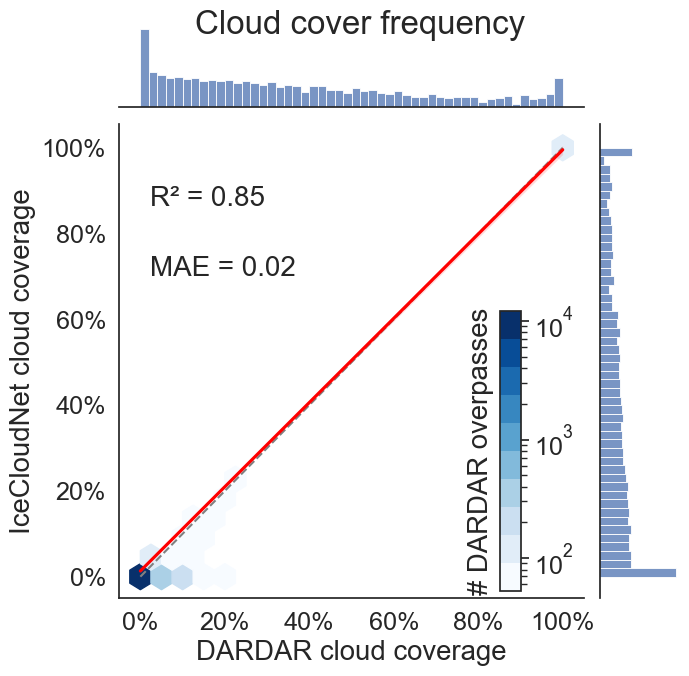

calc zonal/iwp means


/cluster/work/climate/dnikolo/IceCLoudNet_model/ice_cloud_net/src/evaluate/../evaluate/eval_plots.py:427: FutureWarning: The provided callable <function nanmean at 0x14dc179a79c0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_lat_mean = df.groupby("lat").agg(np.nanmean)
/cluster/work/climate/dnikolo/IceCLoudNet_model/ice_cloud_net/src/evaluate/../evaluate/eval_plots.py:427: FutureWarning: The provided callable <function nanmean at 0x14dc179a79c0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_lat_mean = df.groupby("lat").agg(np.nanmean)
/cluster/work/climate/dnikolo/IceCLoudNet_model/ice_cloud_net/src/evaluate/../evaluate/eval_plots.py:529: RuntimeWarning: divide by zero encountered in log10
  diff_z_log = np.log10(y_hat_Z)

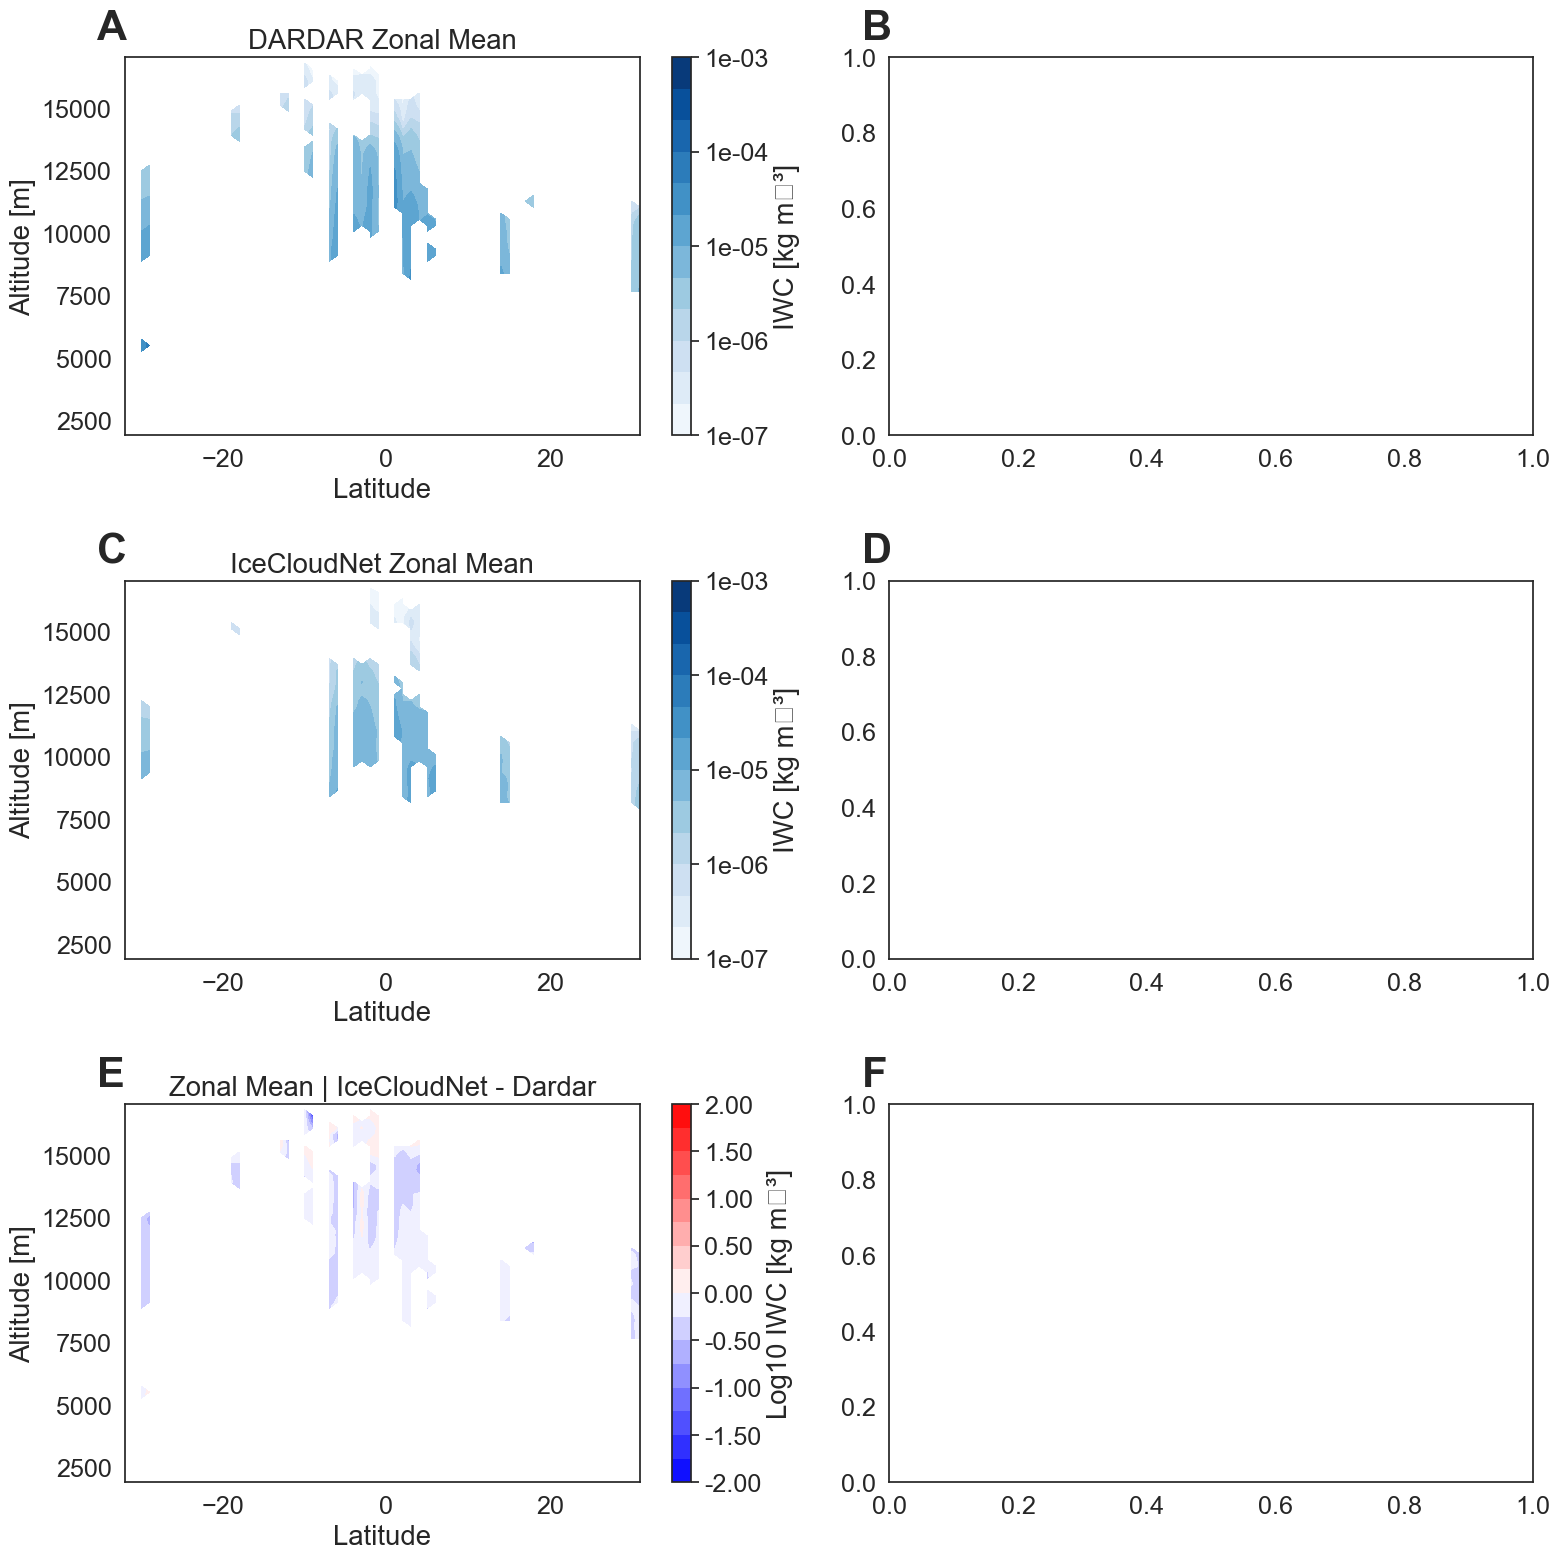

In [58]:
# iwc 
run_evaluation(y_hat_iwc,dardar_iwc,eval_data,exp=None,height_levels=height_levels,target_transform=LogTransform(scaler=1e7),target_variable="iwc",log_image_kwargs=dict(display_inline=True, log_to_overleaf=False, log_to_comet=False))

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
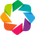

:NdOverlay   [Variable]
   :Curve   [index]   (value)

:NdOverlay   [Variable]
   :Curve   [index]   (value)

min_n_per_height 135.9695
min_n_per_height 157.1175


:Overlay
   .Curve.I  :Curve   [index]   (iwc_median)
   .Area.I   :Area   [index]   (iwc_q25,iwc_q75)
   .Curve.II :Curve   [index]   (iwc_median)
   .Area.II  :Area   [index]   (iwc_q25,iwc_q75)

:Overlay
   .HexTiles.I :HexTiles   [IceCloudNet,Dardar]
   .Curve.I    :Curve   [x]   (y)
   .Curve.II   :Curve   [IceCloudNet]   (mean)
   .Area.I     :Area   [IceCloudNet]   (lower,upper)
   .Text.I     :Text   [x,y]

{'accuracy_night': 0.9586492515266255,
 'corr_incloud_night': 0.6471467390231853,
 'corr_night': 0.6495486677162486,
 'mae_incloud_night': 2.5293016733485274e-05,
 'mae_night': 2.2732610887032934e-06,
 'precision_night': 0.7972560022652139,
 'r2_incloud_night': 0.3790052533149719,
 'r2_log_night': 0.6491347551345825,
 'r2_night': 0.395077645778656,
 'recall_night': 0.6899454230114405}


In [59]:
# iwc night
run_evaluation(y_hat_night_iwc,dardar_night_iwc,eval_data,exp=None,height_levels=height_levels,target_transform=LogTransform(scaler=1e7),target_variable="iwc",suffix="night",log_image_kwargs=dict(display_inline=True, log_to_overleaf=False, log_to_comet=False))

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
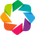

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [57]:
# iwc day
run_evaluation(y_hat_day_iwc,dardar_day_iwc,eval_data,exp=None,height_levels=height_levels,target_transform=LogTransform(scaler=1e7),target_variable="iwc",suffix="day",log_image_kwargs=dict(display_inline=True, log_to_overleaf=False, log_to_comet=False))

In [ ]:
# icnc 
run_evaluation(y_hat_nice,dardar_nice,eval_data,exp=None,height_levels=height_levels,target_transform=nice_logtrans,target_variable="nice",suffix="nice",log_image_kwargs=dict(display_inline=True, log_to_overleaf=False, log_to_comet=False))

In [ ]:
# icnc day
run_evaluation(y_hat_night_nice,dardar_night_nice,eval_data,exp=None,height_levels=height_levels,target_transform=nice_logtrans,target_variable="nice",suffix="nice_night",log_image_kwargs=dict(display_inline=True, log_to_overleaf=False, log_to_comet=False))

In [ ]:
# icnc _night
run_evaluation(y_hat_day_nice,dardar_day_nice,eval_data,exp=None,height_levels=height_levels,target_transform=nice_logtrans,target_variable="nice",suffix="nice_day",log_image_kwargs=dict(display_inline=True, log_to_overleaf=False, log_to_comet=False))